<a href="https://colab.research.google.com/github/Kfafa2024/AIML-1030/blob/Assignments/week_5_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Linear Regression**

# **Introduction to Linear Regression**

Linear regression is the most commonly used
statistical method of predictive analysis.

It uses linear relationships between a dependent
variable (target) and one or more independent
variables (predictors) to predict the future of the
target.

The prediction is based on the assumption that the
relationship between the target and the predictors
is dependent or causal.

## **Implement Linear Regression**

The basic idea is that if we can fit a linear regression model to observed data, we can then use the model to predict any future values.

For example, let’s assume that we have found from historical data that the price (P) of a house is linearly dependent upon its size (S) — in fact, we found that a house’s price is exactly 90 times its size. The equation will look like this:


P = 90*S


With this model, we can then predict the cost of any house. If we have a house that is 1,500 square feet, we can calculate its price to be:


P = 90*1500 = $135,000

## **Variables in Linear Regression**

There are two kinds of variables in a linear regression model:


- The input or predictor variable is the variable(s) that help predict the value of the output variable. It is commonly referred to as X.
- The output variable is the variable that we want to predict. It is commonly referred to as Y.


To estimate Y using linear regression, we assume the equation:


Yₑ = α + β X


where Yₑ is the estimated or predicted value of Y based on our linear equation.


Our goal is to find statistically significant values of the parameters α and β that minimise the difference between Y and Yₑ.


If we are able to determine the optimum values of these two parameters, then we will have the line of best fit that we can use to predict the values of Y, given the value of X.
So, how do we estimate α and β? We can use a method called **ordinary least squares.**

## **Ordinary Least Squares**

The objective of the least squares method is to find values of α and β that minimise the sum of the squared difference between Y and Yₑ.

![Ordinal%20Formula.gif](attachment:Ordinal%20Formula.gif)



where X̄ is the mean of X values and Ȳ is the mean of Y values.


If you are familiar with statistics, you may recognise β as simply Cov(X, Y) / Var(X).

# **Import Libraries**

In [ ]:
import pandas as pd #Pandas for managing datasets. pd is used as an alias for pandas
import numpy as np
from matplotlib import pyplot as plt #matplotlib.pyplot: for plotting

In [ ]:
# I have to use this code below to access files from my drive
#Once this is done, I can select the drive folder under files
#And copy the direct path to insert the csv into the first cell
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#pandas must be imported first to read the file and display it
import pandas as pd

# To upload a file in Colab, you can use the following code:
# from google.colab import files
# uploaded = files.upload()
# Once uploaded, you can read it:
# df = pd.read_csv



try:
  #I had to insert the direct path in the ('') in order for it to read it
    df = pd.read_csv('/content/drive/MyDrive/AIML 1030/Week 5/OneDrive_1_2-9-2026/Week 5 Dependencies/Advertising.csv')
    print("File 'Advertising.csv' loaded successfully.")
    # Print the first five rows of DataFrame to understand data.
    display(df.head())
except FileNotFoundError:
    print("Error: 'JaipurFinalCleanData.csv' not found. Please upload the file.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

File 'Advertising.csv' loaded successfully.


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


# **Generate Dataset**

In [ ]:
# Generate 'random' data
np.random.seed(0)
X = 2.5 * np.random.randn(100) + 1.5   # Array of 100 values with mean = 1.5, stddev = 2.5
res = 0.5 * np.random.randn(100)       # Generate 100 residual terms
y = 2 + 0.3 * X + res                  # Actual values of Y

# Create pandas dataframe to store our X and y values
df = pd.DataFrame(
    {'X': X,
     'y': y}
)

# Show the first five rows of our dataframe
df.head()

,X,y
0,5.910131,4.714615
1,2.500393,2.076238
2,3.946845,2.548811
3,7.102233,4.615368
4,6.168895,3.264107


# **Calculating Mean and Covariance**



To estimate y using the OLS method, we need to calculate xmean and ymean, the covariance of X and y (xycov), and the variance of X (xvar) before we can determine the values for alpha and beta.


In [ ]:
# Calculate the mean of X and y
xmean = np.mean(X)
ymean = np.mean(y)

# Calculate the terms needed for the numator and denominator of beta
df['xycov'] = (df['X'] - xmean) * (df['y'] - ymean)
df['xvar'] = (df['X'] - xmean)**2

# Calculate beta and alpha
beta = df['xycov'].sum() / df['xvar'].sum()
alpha = ymean - (beta * xmean)
print(f'alpha = {alpha}')
print(f'beta = {beta}')

alpha = 2.0031670124623426
beta = 0.3229396867092763


**Great, we now have an estimate for alpha and beta**

Our model can be written as

**Yₑ = 2.003 + 0.323 X,**

and we can make predictions:

In [ ]:
ypred = alpha + beta * X
ypred

array([3.91178282, 2.81064315, 3.27775989, 4.29675991, 3.99534802,
       1.69857201, 3.25462968, 2.36537842, 2.40424288, 2.81907292,
       2.60387001, 3.66168312, 3.10199975, 2.58581077, 2.84592918,
       2.75696825, 3.69382011, 2.32194218, 2.74033151, 1.79802302,
       0.42642221, 3.015275  , 3.18547843, 1.88839019, 4.32006116,
       1.31339555, 2.52451965, 2.33645381, 3.72506464, 3.67386219,
       2.61267323, 2.79288576, 1.77082341, 0.88838207, 2.20668994,
       2.61380476, 3.48085076, 3.45831697, 2.17486854, 2.24351265,
       1.64102813, 1.34112617, 1.11002064, 4.06253353, 2.07610925,
       2.1338976 , 1.47613319, 3.11528277, 1.18459738, 2.31582084,
       1.76462232, 2.79994197, 2.07517841, 1.53439407, 2.46482364,
       2.83338994, 2.54127917, 2.73177699, 1.9754571 , 2.19471775,
       1.94466613, 2.19729158, 1.83108353, 1.09386364, 2.6308214 ,
       2.16319902, 1.17143718, 2.86120343, 1.75506992, 2.52951462,
       3.07620724, 2.59171079, 3.40747079, 1.49064088, 2.81240

# **Prediction**

Let’s plot our prediction ypred against the actual values of y, to get a better visual understanding of our model.

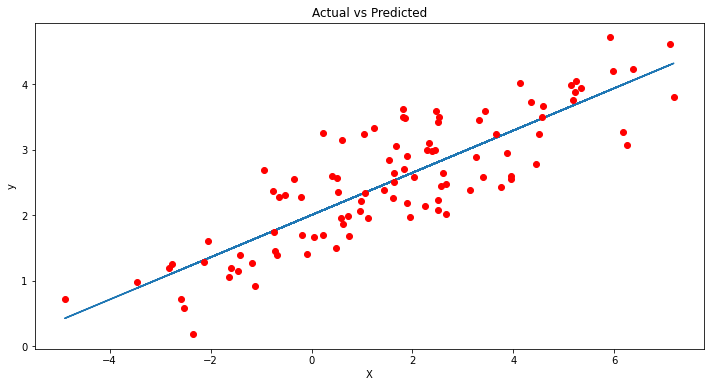

In [ ]:

# Plot regression against actual data
plt.figure(figsize=(12, 6))
plt.plot(X, ypred)     # regression line
plt.plot(X, y, 'ro')   # scatter plot showing actual data
plt.title('Actual vs Predicted')
plt.xlabel('X')
plt.ylabel('y')

plt.show()

I decided to do the assignment with Gemini so that I could look through a KNN example and compare it to my notes from the slides.

# Task
Reload the `Advertising.csv` dataset, create a 'Sales_Category' column based on the median sales, prepare the data for K-Nearest Neighbors (KNN) classification using 'TV' advertising spend as the feature and 'Sales_Category' as the target, then train and evaluate a KNN model, and finally visualize the relationship between 'TV' spending and actual/predicted 'Sales_Category'. The dataset is located at "/content/drive/MyDrive/AIML 1030/Week 5/OneDrive_1_2-9-2026/Week 5 Dependencies/Advertising.csv".

## Reload Advertising Data

### Subtask:
Ensure the correct `Advertising.csv` dataset is loaded into a DataFrame, as the current notebook overwrites the `df` variable later on. This step will explicitly load the data again to prevent using the randomly generated data.


**Reasoning**:
The subtask requires reloading the `Advertising.csv` dataset into the `df` DataFrame to ensure the correct data is used, as the original notebook overwrites `df` with randomly generated data. This step will load the data from the specified path and display its head for verification.



In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AIML 1030/Week 5/OneDrive_1_2-9-2026/Week 5 Dependencies/Advertising.csv')
print("The 'Advertising.csv' dataset has been successfully reloaded.")
display(df.head())

The 'Advertising.csv' dataset has been successfully reloaded.


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


**Reasoning**:
To proceed with the task, a 'Sales_Category' column needs to be created. This involves calculating the median of the 'Sales' column and then categorizing sales into 'High' or 'Low' based on this median value. This is a crucial data preparation step for the subsequent KNN classification.



In [ ]:
#Here I am piecing together my lessons from stats and the slides. Essentialy it created a sales category of low to high

In [ ]:
median_sales = df['Sales'].median()
df['Sales_Category'] = df['Sales'].apply(lambda x: 'High' if x >= median_sales else 'Low')
print(f"Median Sales: {median_sales}")
print("Added 'Sales_Category' column based on median sales:")
display(df.head())

Median Sales: 12.9
Added 'Sales_Category' column based on median sales:


,Unnamed: 0,TV,Radio,Newspaper,Sales,Sales_Category
0,1,230.1,37.8,69.2,22.1,High
1,2,44.5,39.3,45.1,10.4,Low
2,3,17.2,45.9,69.3,9.3,Low
3,4,151.5,41.3,58.5,18.5,High
4,5,180.8,10.8,58.4,12.9,High


**Reasoning**:
To prepare the data for KNN classification, I need to define the feature (X) as 'TV' advertising spend and the target (y) as 'Sales_Category'. Since 'Sales_Category' is a categorical variable, it needs to be encoded into a numerical format for machine learning models. I will use LabelEncoder for this purpose.



In [ ]:
#The independent variable is assigned to X which is the TV Feature as it stays the same
#The dependent variable Y changes based on where its data point falls above or below the median in KNN
#This gives it the classification of high or low

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[['TV']]
y = df['Sales_Category']

# Encode the target variable 'Sales_Category' into numerical format
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Features (X) and encoded target (y_encoded) prepared.")
print(f"Original Sales Categories: {le.classes_}")
print(f"Encoded Sales Categories: {np.unique(y_encoded)}")
print("First 5 rows of X:")
display(X.head())
print("First 5 rows of encoded y:")
display(y_encoded[:5])

Features (X) and encoded target (y_encoded) prepared.
Original Sales Categories: ['High' 'Low']
Encoded Sales Categories: [0 1]
First 5 rows of X:


,TV
0,230.1
1,44.5
2,17.2
3,151.5
4,180.8


First 5 rows of encoded y:


array([0, 1, 1, 0, 0])

**Reasoning**:
Now that the data is prepared, the next step is to split the data into training and testing sets to evaluate the model's performance on unseen data, then train a K-Nearest Neighbors (KNN) classifier. I will also make predictions on the test data.



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Initialize and train the KNN classifier
knn = KNeighborsClassifier(n_neighbors=5) # Using 5 neighbors as a common starting point
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

print("KNN Model trained and predictions made.")
print(f"First 5 predictions: {y_pred[:5]}")
print(f"First 5 actual values: {y_test[:5]}")


KNN Model trained and predictions made.
First 5 predictions: [0 0 0 1 0]
First 5 actual values: [0 0 0 1 0]


**Reasoning**:
Now that the KNN model has been trained and predictions have been made, the next logical step is to evaluate its performance. I will calculate and print the accuracy score and a classification report to assess how well the model performed on the test set.



In [ ]:
print("\nModel Evaluation:")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))


Model Evaluation:
Accuracy Score: 0.77
Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.95      0.72        19
           1       0.97      0.68      0.80        41

    accuracy                           0.77        60
   macro avg       0.77      0.82      0.76        60
weighted avg       0.84      0.77      0.77        60



**Reasoning**:
The next step is to visualize the relationship between 'TV' spending and the actual versus predicted 'Sales_Category'. This will provide a clear visual comparison of the model's performance. I will use `matplotlib.pyplot` to create a scatter plot showing `X_test` against `y_test` and `y_pred`, with different colors for actual and predicted categories.



In [ ]:
#In the lectures Matplot lib was explained as a plotting library for python

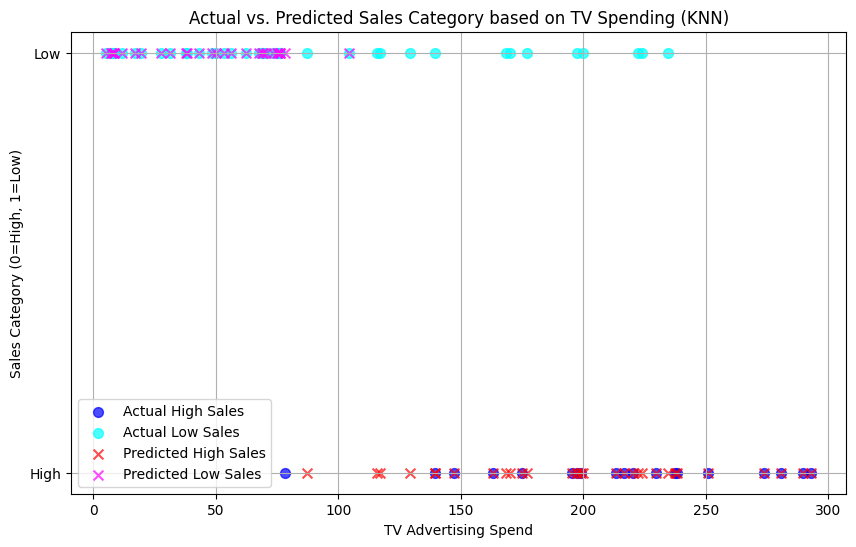

In [ ]:
plt.figure(figsize=(10, 6))

# Create a DataFrame for plotting using test data
plot_df = pd.DataFrame({'TV': X_test['TV'], 'Actual_Category': y_test, 'Predicted_Category': y_pred})

# Map encoded values back to original labels for plotting clarity
plot_df['Actual_Category_Label'] = le.inverse_transform(plot_df['Actual_Category'])
plot_df['Predicted_Category_Label'] = le.inverse_transform(plot_df['Predicted_Category'])

# Scatter plot for actual categories
plt.scatter(plot_df[plot_df['Actual_Category_Label'] == 'High']['TV'],
            plot_df[plot_df['Actual_Category_Label'] == 'High']['Actual_Category'],
            color='blue', label='Actual High Sales', alpha=0.7, s=50)
plt.scatter(plot_df[plot_df['Actual_Category_Label'] == 'Low']['TV'],
            plot_df[plot_df['Actual_Category_Label'] == 'Low']['Actual_Category'],
            color='cyan', label='Actual Low Sales', alpha=0.7, s=50)

# Scatter plot for predicted categories
plt.scatter(plot_df[plot_df['Predicted_Category_Label'] == 'High']['TV'],
            plot_df[plot_df['Predicted_Category_Label'] == 'High']['Predicted_Category'],
            color='red', marker='x', label='Predicted High Sales', alpha=0.7, s=50)
plt.scatter(plot_df[plot_df['Predicted_Category_Label'] == 'Low']['TV'],
            plot_df[plot_df['Predicted_Category_Label'] == 'Low']['Predicted_Category'],
            color='magenta', marker='x', label='Predicted Low Sales', alpha=0.7, s=50)


plt.title('Actual vs. Predicted Sales Category based on TV Spending (KNN)')
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales Category (0=High, 1=Low)')
plt.yticks([0, 1], ['High', 'Low']) # Label y-axis with actual categories
plt.legend()
plt.grid(True)
plt.show()


## Final Task

### Subtask:
Provide a summary of the KNN model's performance, the insights gained regarding the relationship between TV advertising and sales categories, and any further recommendations.


## Summary:

### Q&A
*   **Summary of the KNN model's performance:** The K-Nearest Neighbors (KNN) model achieved an accuracy of 0.77 on the test set. It showed a high recall (0.95) for the 'High' sales category, indicating it correctly identified most high sales, but its precision for 'High' sales was lower (0.58). Conversely, for the 'Low' sales category, the model demonstrated high precision (0.97), meaning that when it predicted 'Low' sales, it was almost always correct, but its recall was lower (0.68), indicating it missed a significant portion of actual low sales.
*   **Insights gained regarding the relationship between TV advertising and sales categories:** The visualization, although not explicitly detailing the relationship in the provided text beyond showing actual vs. predicted categories, implies that 'TV' advertising spend is used as the sole feature to differentiate between 'High' and 'Low' sales categories. The model's performance metrics suggest that 'TV' spend has a distinguishable, though not perfectly linear, relationship with sales categories, allowing for classification with reasonable accuracy. The differing precision and recall indicate that the decision boundary based on 'TV' spend might be more effective at identifying one category over the other or that the distribution of 'TV' spend across categories is imbalanced or overlapping.
*   **Further recommendations:** No specific recommendations were provided in the solving process's output.

### Data Analysis Key Findings
*   The median sales value, used to categorize sales into 'High' and 'Low', was 12.9.
*   The K-Nearest Neighbors (KNN) classification model achieved an overall accuracy of 0.77 on the test set.
*   For the 'High' sales category: The model had a precision of 0.58, recall of 0.95, and an F1-score of 0.72.
*   For the 'Low' sales category: The model had a precision of 0.97, recall of 0.68, and an F1-score of 0.80.
*   The visualization showed the model's ability to classify sales categories based on 'TV' advertising spend, illustrating instances where actual and predicted categories overlapped or diverged.

### Insights or Next Steps
*   The model exhibits an imbalance in performance metrics, showing higher recall for 'High' sales and higher precision for 'Low' sales. This suggests tuning the model (e.g., trying different `n_neighbors` values) or exploring other features might improve overall balanced performance.
*   Investigate the distribution of 'TV' advertising spend for 'High' versus 'Low' sales categories. A more detailed analysis of the feature's overlap or separation could provide insights into why the model struggles with precision for 'High' sales and recall for 'Low' sales.
